<a href="https://colab.research.google.com/github/SDanielBriggs/Crime-Patterns-and-Hotspots-in-the-West-Midlands/blob/main/Number_of_Crimes_per_month.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import glob

files = glob.glob("/content/West Mid Police Data/*.csv")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["Month"] = pd.to_datetime(df["Month"])

In [2]:
monthly_crime = df.groupby("Month").size()

# Plotting a graph of the number of crimes per month

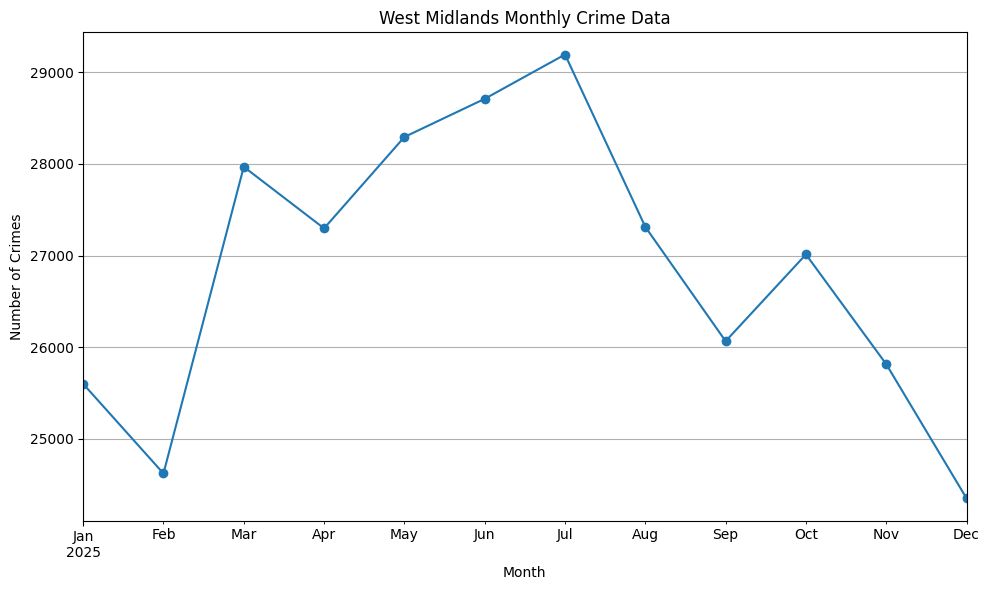

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
monthly_crime.plot(kind='line', marker='o')
plt.title('West Midlands Monthly Crime Data')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.grid(True)
plt.tight_layout()
plt.show()

### Analysing Crime by Type

Breaking down the crime data by category to see the trends for different types of offenses.

In [4]:
crime_by_type_monthly = df.groupby(['Month', 'Crime type']).size().unstack(fill_value=0)

display(crime_by_type_monthly.head())

Crime type,Anti-social behaviour,Bicycle theft,Burglary,Criminal damage and arson,Drugs,Other crime,Other theft,Possession of weapons,Public order,Robbery,Shoplifting,Theft from the person,Vehicle crime,Violence and sexual offences
Month,,,,,,,,,,,,,,
2025-01-01,1920,110,1231,1868,772,567,1526,455,1299,458,2606,166,2076,10547
2025-02-01,2086,100,1112,1719,772,584,1387,484,1208,408,2599,203,2173,9789
2025-03-01,2472,144,1133,2086,764,596,1558,556,1503,475,3003,201,2213,11263
2025-04-01,2565,152,1217,2046,699,471,1594,523,1360,598,2871,229,2355,10616
2025-05-01,2477,165,1190,2119,733,519,1611,604,1616,556,2781,233,2415,11273


Visualising the trends for the top 5 most common crime types to see how they change month over month.

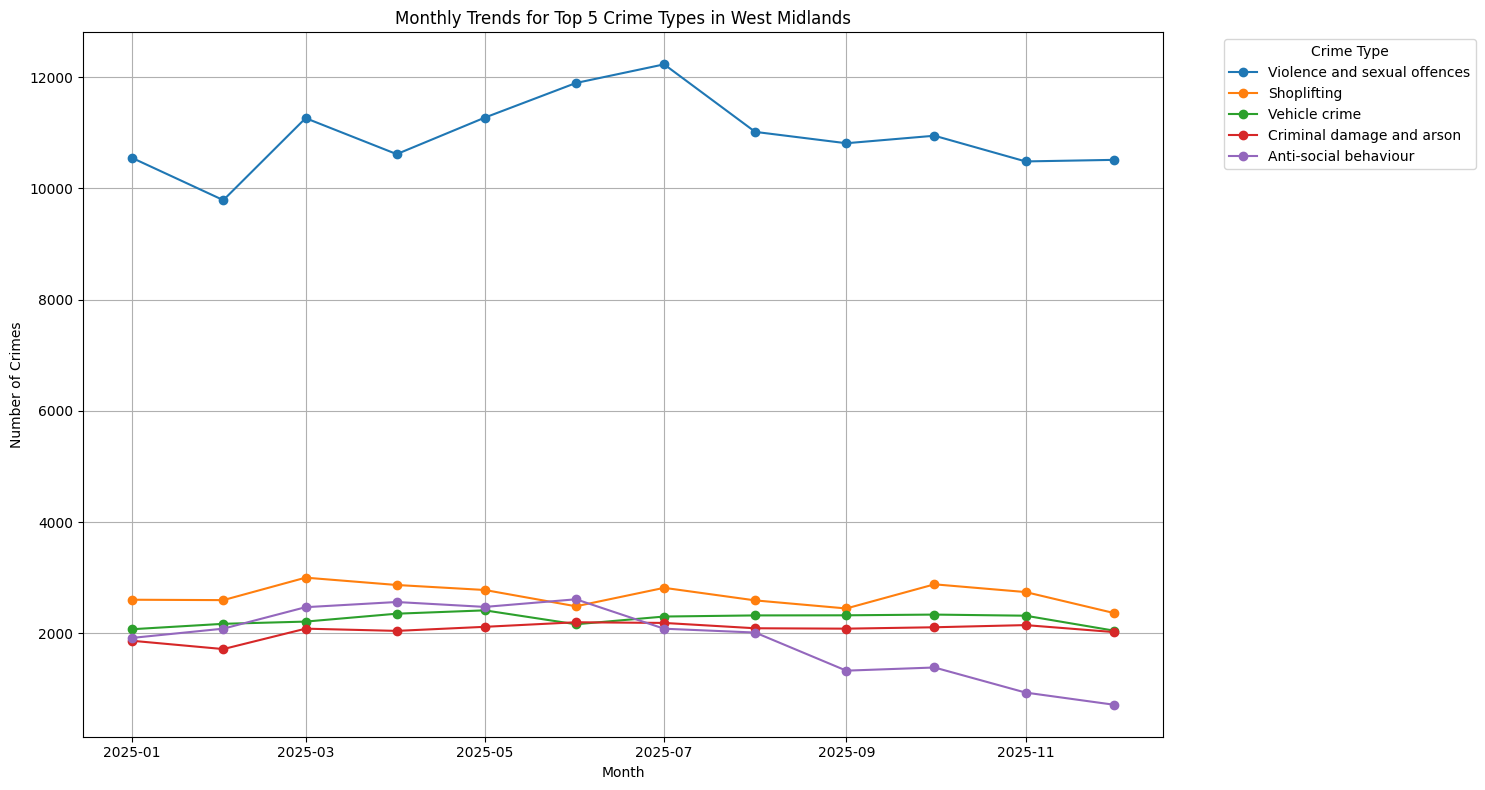

In [5]:
import matplotlib.pyplot as plt

# Identify the top 5 crime types based on total occurrences
top_5_crime_types = crime_by_type_monthly.sum().nlargest(5).index

plt.figure(figsize=(15, 8))
for crime_type in top_5_crime_types:
    plt.plot(crime_by_type_monthly.index, crime_by_type_monthly[crime_type], marker='o', label=crime_type)

plt.title('Monthly Trends for Top 5 Crime Types in West Midlands')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.grid(True)
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()